In [1]:
import rasterio
import numpy as np
from rasterio.transform import from_bounds
import os
import matplotlib.pyplot as plt

# Data Inspection

In [2]:
def inspect_raster(file_path, name):
    """Comprehensive inspection of a raster file."""
    print("=" * 60)
    print(f"INSPECTING: {name}")
    print("=" * 60)
    
    with rasterio.open(file_path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        profile = src.profile
        
    print(f"Shape: {data.shape}")
    print(f"Dtype: {data.dtype}")
    print(f"NoData value: {nodata}")
    print(f"CRS: {profile.get('crs', 'N/A')}")
    
    # Replace nodata with NaN
    if nodata is not None:
        data[data == nodata] = np.nan
    
    # Basic statistics
    print("\n--- BASIC STATISTICS ---")
    print(f"Total pixels: {data.size:,}")
    print(f"NaN pixels: {np.isnan(data).sum():,} ({np.isnan(data).sum()/data.size*100:.2f}%)")
    print(f"Valid pixels: {(~np.isnan(data)).sum():,} ({(~np.isnan(data)).sum()/data.size*100:.2f}%)")
    
    valid_data = data[~np.isnan(data)]
    
    if len(valid_data) > 0:
        print(f"\n--- VALID DATA RANGE ---")
        print(f"Min: {valid_data.min():.6f}")
        print(f"Max: {valid_data.max():.6f}")
        print(f"Mean: {valid_data.mean():.6f}")
        print(f"Median: {np.median(valid_data):.6f}")
        print(f"Std: {valid_data.std():.6f}")
        
        # Check for problematic values
        print(f"\n--- PROBLEMATIC VALUES ---")
        print(f"Negative values: {(valid_data < 0).sum():,}")
        print(f"Zero values: {(valid_data == 0).sum():,}")
        print(f"Infinite values: {np.isinf(valid_data).sum():,}")
        print(f"Extreme negatives (< -1e10): {(valid_data < -1e10).sum():,}")
        print(f"Extreme positives (> 1e10): {(valid_data > 1e10).sum():,}")
        
        # Percentiles
        print(f"\n--- PERCENTILES ---")
        percentiles = [1, 5, 25, 50, 75, 95, 99]
        for p in percentiles:
            print(f"{p}th percentile: {np.percentile(valid_data, p):.6f}")
        
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Histogram
        axes[0].hist(valid_data, bins=100, edgecolor='black', alpha=0.7)
        axes[0].set_title(f'{name} - Distribution')
        axes[0].set_xlabel('Value')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, alpha=0.3)
        
        # Log-scale histogram (if positive values exist)
        if valid_data.min() >= 0:
            log_data = np.log1p(valid_data)
            axes[1].hist(log_data, bins=100, edgecolor='black', alpha=0.7, color='green')
            axes[1].set_title(f'{name} - Log-transformed')
            axes[1].set_xlabel('log(1 + Value)')
            axes[1].set_ylabel('Frequency')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, 'Contains negative values\nLog transform not applicable', 
                        ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title(f'{name} - Log Transform N/A')
        
        # Spatial map
        display_data = data.copy()
        im = axes[2].imshow(display_data, cmap='viridis', interpolation='nearest')
        axes[2].set_title(f'{name} - Spatial Distribution')
        plt.colorbar(im, ax=axes[2])
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ WARNING: No valid data found!")
    
    print("\n")
    return data

# .25 degree inspection


######################################################################
### 0.25 DEGREE RESOLUTION FILES ###
######################################################################

INSPECTING: GDP 0.25°
Shape: (194, 228)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 44,232
NaN pixels: 0 (0.00%)
Valid pixels: 44,232 (100.00%)

--- VALID DATA RANGE ---
Min: -340282306073709652508363335590014353408.000000
Max: 85.080002
Mean: -inf
Median: -inf
Std: inf

--- PROBLEMATIC VALUES ---
Negative values: 29,955
Zero values: 259
Infinite values: 0
Extreme negatives (< -1e10): 29,955
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: -340282306073709652508363335590014353408.000000
5th percentile: -340282306073709652508363335590014353408.000000
25th percentile: -340282306073709652508363335590014353408.000000
50th percentile: -340282306073709652508363335590014353408.000000
75th percentile: 0.223097
95th percentile: 5.017422
99th percentile: 1

c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:171: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\image.py:499: RuntimeWarning: overflow encountered in cast
  A_scaled /= ((a_max - a_min) / frac)
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\image.py:500: RuntimeWarning: overflow encountered in cast
  vrange /= ((a_max - a_min) / frac)
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\image.py:513: RuntimeWarning: overflow encountered in cast
  A_resampled *= ((a_max - a_min) / frac)
c:\User

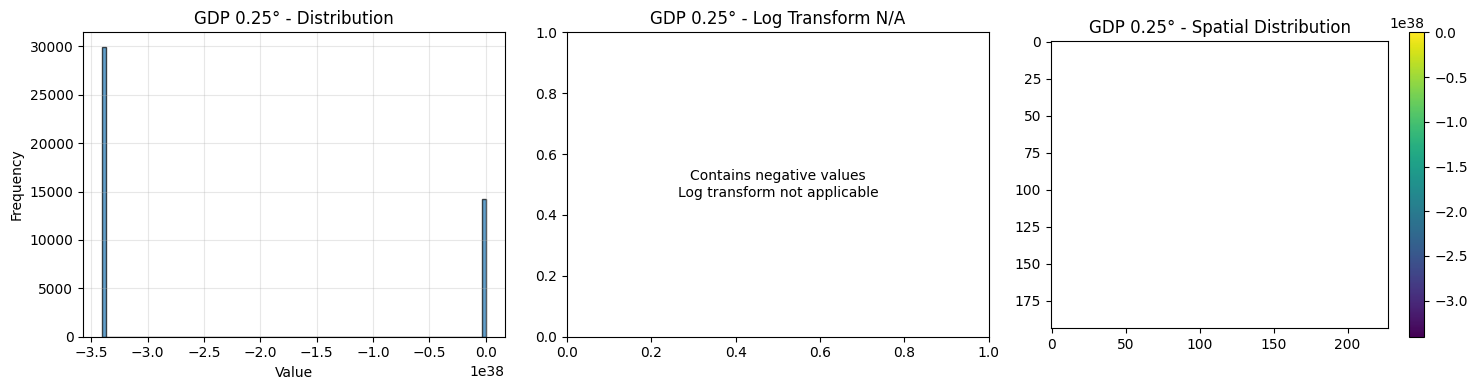



INSPECTING: Population 0.25°
Shape: (194, 228)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 44,232
NaN pixels: 0 (0.00%)
Valid pixels: 44,232 (100.00%)

--- VALID DATA RANGE ---
Min: -340282346638528859811704183484516925440.000000
Max: 7465659.500000
Mean: -inf
Median: -inf
Std: inf

--- PROBLEMATIC VALUES ---
Negative values: 26,272
Zero values: 1,038
Infinite values: 0
Extreme negatives (< -1e10): 26,272
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: -340282346638528859811704183484516925440.000000
5th percentile: -340282346638528859811704183484516925440.000000
25th percentile: -340282346638528859811704183484516925440.000000
50th percentile: -340282346638528859811704183484516925440.000000
75th percentile: 2972.197998
95th percentile: 74543.921875
99th percentile: 270770.906250


c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: overflow encountered in multiply
  y *= step


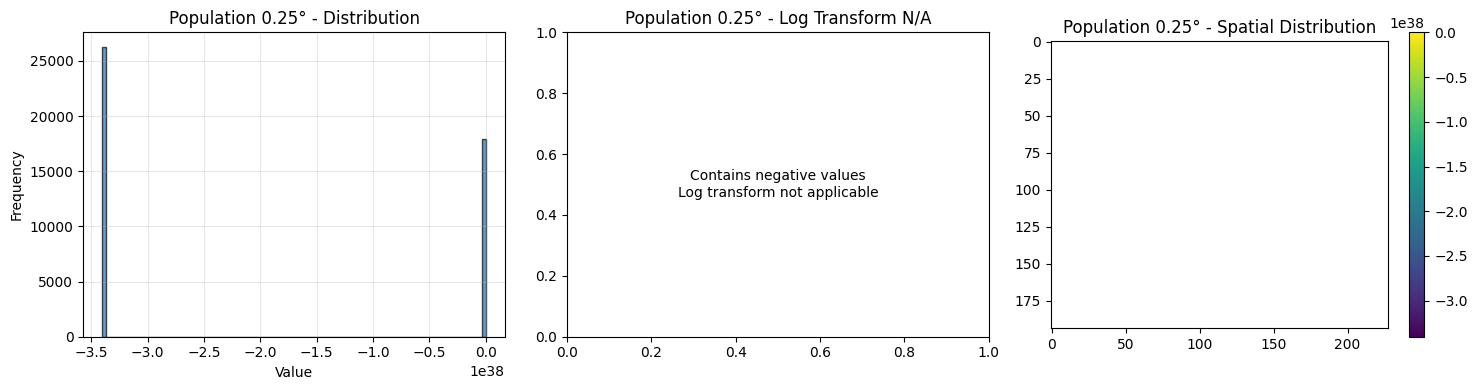



INSPECTING: Land Cover 0.25° (Channel 1 of 7)
Total channels: 7
Shape per channel: (194, 228)
Valid values in Channel 1: 44,232


INSPECTING: CISI 0.25°
Shape: (194, 228)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 44,232
NaN pixels: 29,310 (66.26%)
Valid pixels: 14,922 (33.74%)

--- VALID DATA RANGE ---
Min: 0.000000
Max: 0.732408
Mean: 0.032929
Median: 0.020444
Std: 0.040718

--- PROBLEMATIC VALUES ---
Negative values: 0
Zero values: 780
Infinite values: 0
Extreme negatives (< -1e10): 0
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: 0.000000
5th percentile: 0.000000
25th percentile: 0.006022
50th percentile: 0.020444
75th percentile: 0.044930
95th percentile: 0.109898
99th percentile: 0.188196


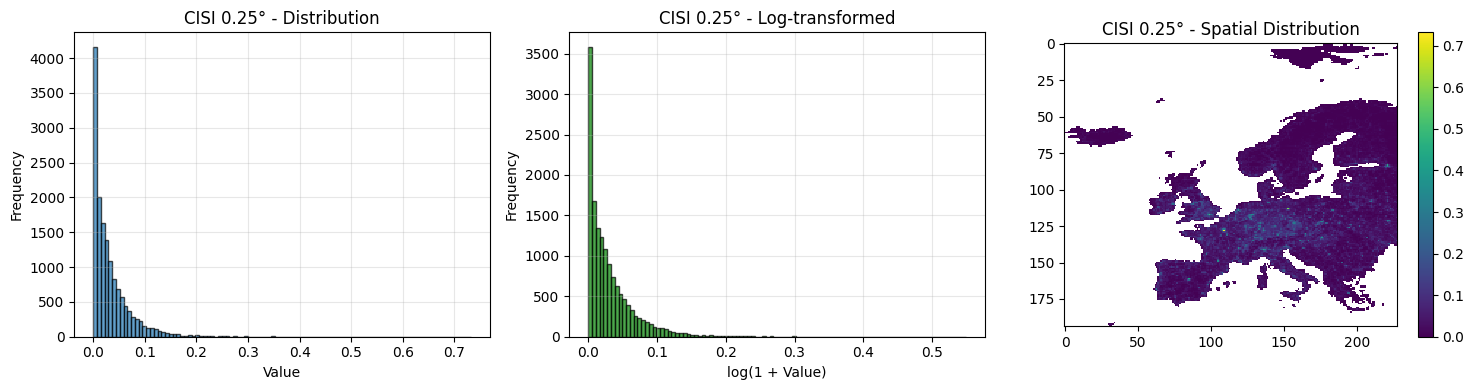

In [3]:
print("\n" + "#" * 70)
print("### 0.25 DEGREE RESOLUTION FILES ###")
print("#" * 70 + "\n")

# GDP 0.25 degree
gdp_025 = inspect_raster(
    r'READY_data\inputs\2019_gdp_aligned_025.tif',
    'GDP 0.25°'
)

# Population 0.25 degree
pop_025 = inspect_raster(
    r'READY_data\inputs\2020_pop_aligned_025.tif',
    'Population 0.25°'
)

# Land Cover 0.25 degree (just first channel)
with rasterio.open(r'READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif') as src:
    lc_025_first = src.read(1).astype(np.float32)
    print("=" * 60)
    print(f"INSPECTING: Land Cover 0.25° (Channel 1 of {src.count})")
    print("=" * 60)
    print(f"Total channels: {src.count}")
    print(f"Shape per channel: {lc_025_first.shape}")
    print(f"Valid values in Channel 1: {(lc_025_first >= 0).sum():,}")
    print("\n")

# CISI 0.25 degree
cisi_025 = inspect_raster(
    r'READY_data\labels\2024_CISI_025deg.tif',
    'CISI 0.25°'
)

# Check overlap for 0.25 degree

### 0.25 DEGREE - DATA OVERLAP ANALYSIS ###

Total pixels: 44,232

Valid pixels per dataset:
  GDP:  44,232 (100.00%)
  Pop:  44,232 (100.00%)
  CISI: 14,922 (33.74%)

✅ Pixels valid in ALL datasets: 14,922 (33.74%)


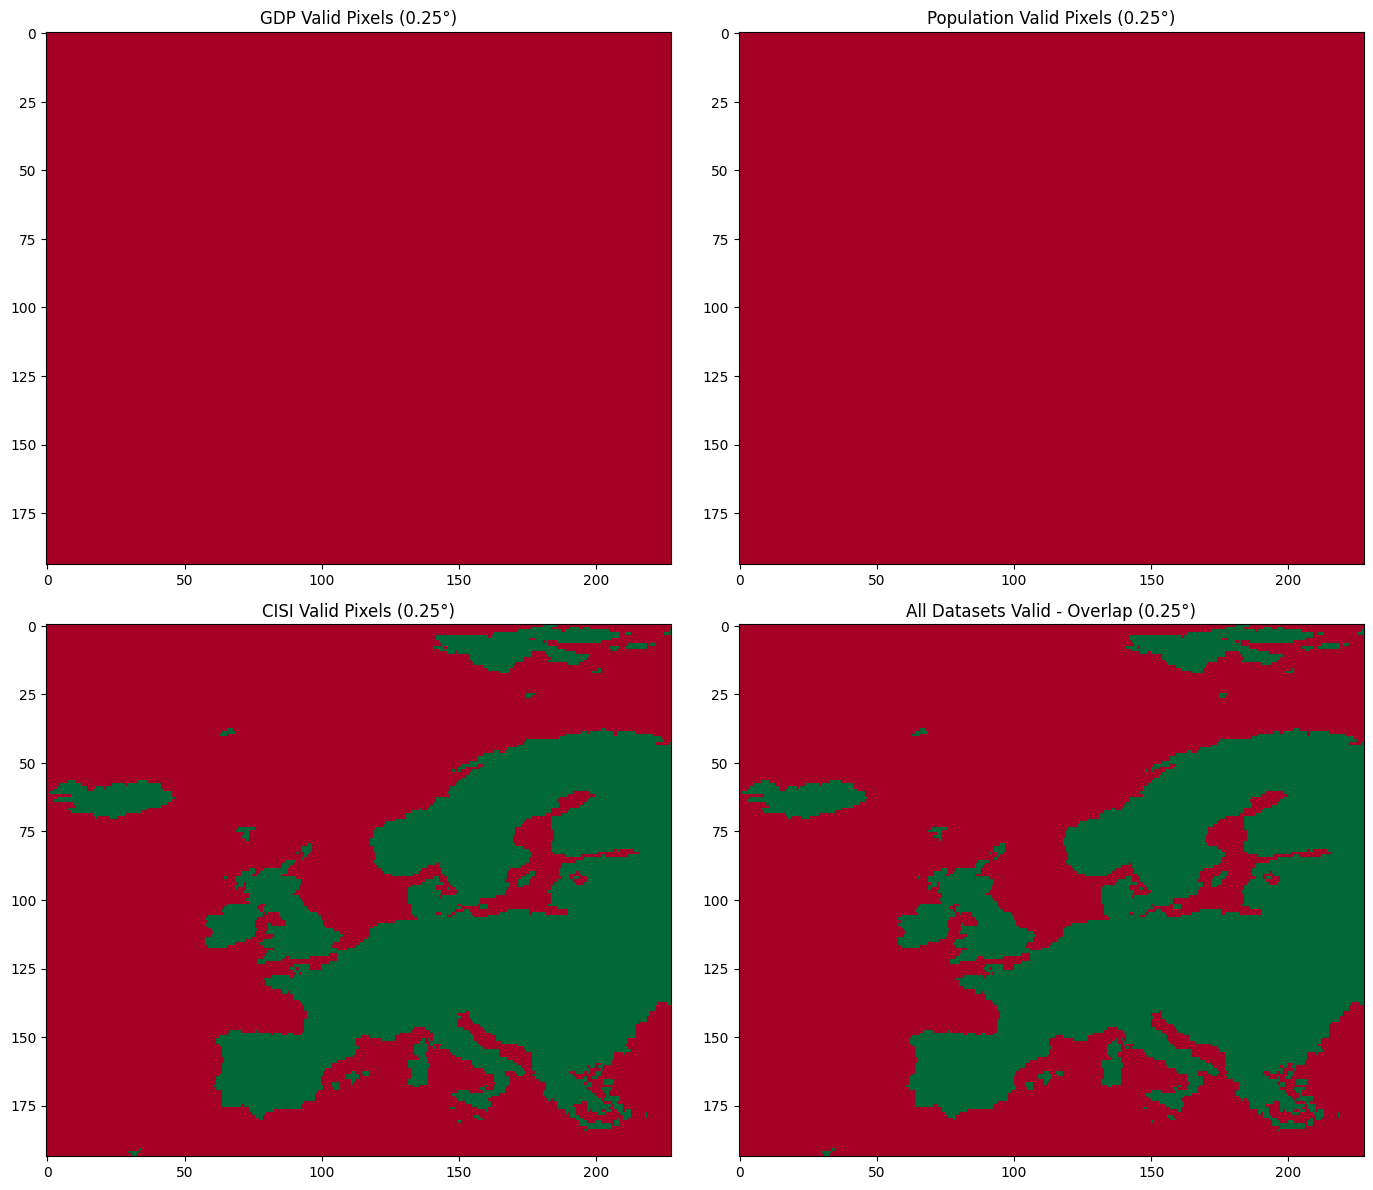

In [4]:
print("=" * 70)
print("### 0.25 DEGREE - DATA OVERLAP ANALYSIS ###")
print("=" * 70)

# Create masks
gdp_valid_025 = ~np.isnan(gdp_025)
pop_valid_025 = ~np.isnan(pop_025)
cisi_valid_025 = ~np.isnan(cisi_025)

total_pixels_025 = gdp_025.size

print(f"\nTotal pixels: {total_pixels_025:,}")
print(f"\nValid pixels per dataset:")
print(f"  GDP:  {gdp_valid_025.sum():,} ({gdp_valid_025.sum()/total_pixels_025*100:.2f}%)")
print(f"  Pop:  {pop_valid_025.sum():,} ({pop_valid_025.sum()/total_pixels_025*100:.2f}%)")
print(f"  CISI: {cisi_valid_025.sum():,} ({cisi_valid_025.sum()/total_pixels_025*100:.2f}%)")

# Overlap
all_valid_025 = gdp_valid_025 & pop_valid_025 & cisi_valid_025
print(f"\n✅ Pixels valid in ALL datasets: {all_valid_025.sum():,} ({all_valid_025.sum()/total_pixels_025*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(gdp_valid_025, cmap='RdYlGn', interpolation='nearest')
axes[0, 0].set_title('GDP Valid Pixels (0.25°)')

axes[0, 1].imshow(pop_valid_025, cmap='RdYlGn', interpolation='nearest')
axes[0, 1].set_title('Population Valid Pixels (0.25°)')

axes[1, 0].imshow(cisi_valid_025, cmap='RdYlGn', interpolation='nearest')
axes[1, 0].set_title('CISI Valid Pixels (0.25°)')

axes[1, 1].imshow(all_valid_025, cmap='RdYlGn', interpolation='nearest')
axes[1, 1].set_title('All Datasets Valid - Overlap (0.25°)')

plt.tight_layout()
plt.show()

print("\n")

# Inspect 0.1 degree 


######################################################################
### 0.1 DEGREE RESOLUTION FILES ###
######################################################################

INSPECTING: GDP 0.1°
Shape: (485, 570)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 276,450
NaN pixels: 0 (0.00%)
Valid pixels: 276,450 (100.00%)

--- VALID DATA RANGE ---
Min: -340282306073709652508363335590014353408.000000
Max: 101.492683
Mean: -inf
Median: -inf
Std: inf

--- PROBLEMATIC VALUES ---
Negative values: 187,053
Zero values: 1,743
Infinite values: 0
Extreme negatives (< -1e10): 187,053
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: -340282306073709652508363335590014353408.000000
5th percentile: -340282306073709652508363335590014353408.000000
25th percentile: -340282306073709652508363335590014353408.000000
50th percentile: -340282306073709652508363335590014353408.000000
75th percentile: 0.125900
95th percentile: 4.626160
99th percenti

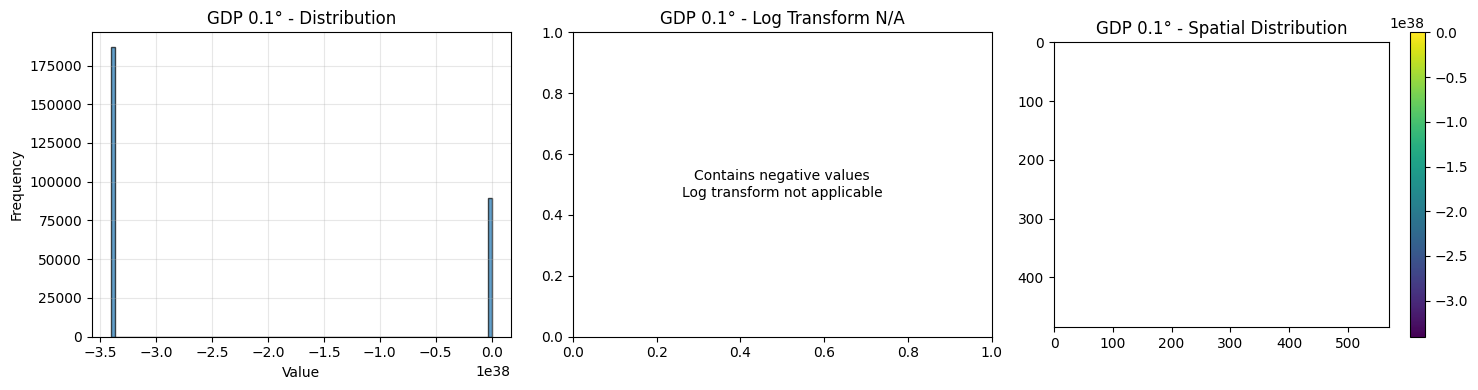



INSPECTING: Population 0.1°
Shape: (485, 570)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 276,450
NaN pixels: 0 (0.00%)
Valid pixels: 276,450 (100.00%)

--- VALID DATA RANGE ---
Min: -340282346638528859811704183484516925440.000000
Max: 3436316.250000
Mean: -inf
Median: -inf
Std: inf

--- PROBLEMATIC VALUES ---
Negative values: 171,511
Zero values: 5,883
Infinite values: 0
Extreme negatives (< -1e10): 171,511
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: -340282346638528859811704183484516925440.000000
5th percentile: -340282346638528859811704183484516925440.000000
25th percentile: -340282346638528859811704183484516925440.000000
50th percentile: -340282346638528859811704183484516925440.000000
75th percentile: 220.291229
95th percentile: 9644.903320
99th percentile: 46952.457031


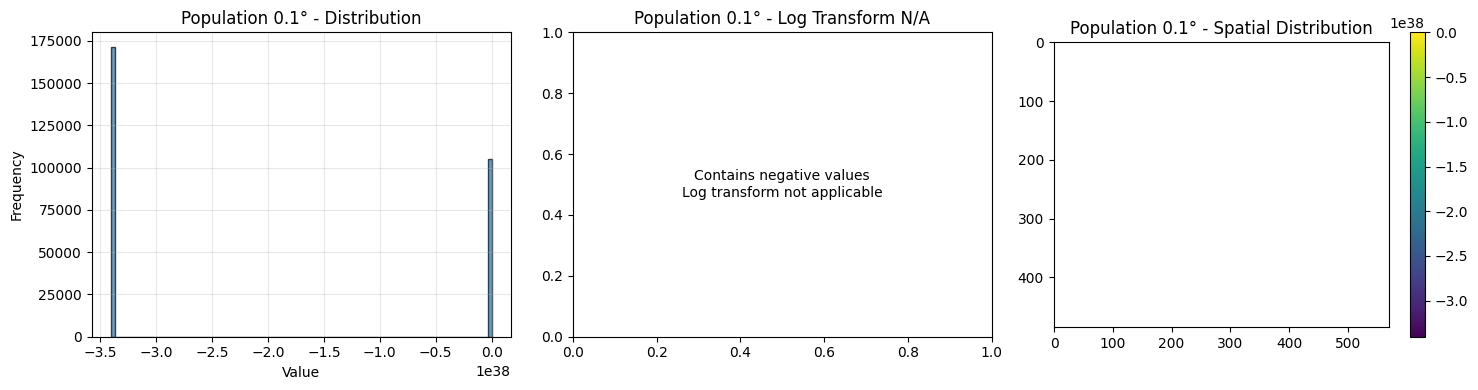



INSPECTING: Land Cover 0.1° (Channel 1 of 7)
Total channels: 7
Shape per channel: (485, 570)
Valid values in Channel 1: 276,450


INSPECTING: CISI 0.1°
Shape: (485, 570)
Dtype: float32
NoData value: None
CRS: EPSG:4326

--- BASIC STATISTICS ---
Total pixels: 276,450
NaN pixels: 189,104 (68.40%)
Valid pixels: 87,346 (31.60%)

--- VALID DATA RANGE ---
Min: 0.000000
Max: 0.802571
Mean: 0.028428
Median: 0.017349
Std: 0.035905

--- PROBLEMATIC VALUES ---
Negative values: 0
Zero values: 5,656
Infinite values: 0
Extreme negatives (< -1e10): 0
Extreme positives (> 1e10): 0

--- PERCENTILES ---
1th percentile: 0.000000
5th percentile: 0.000000
25th percentile: 0.005231
50th percentile: 0.017349
75th percentile: 0.038313
95th percentile: 0.094125
99th percentile: 0.165457


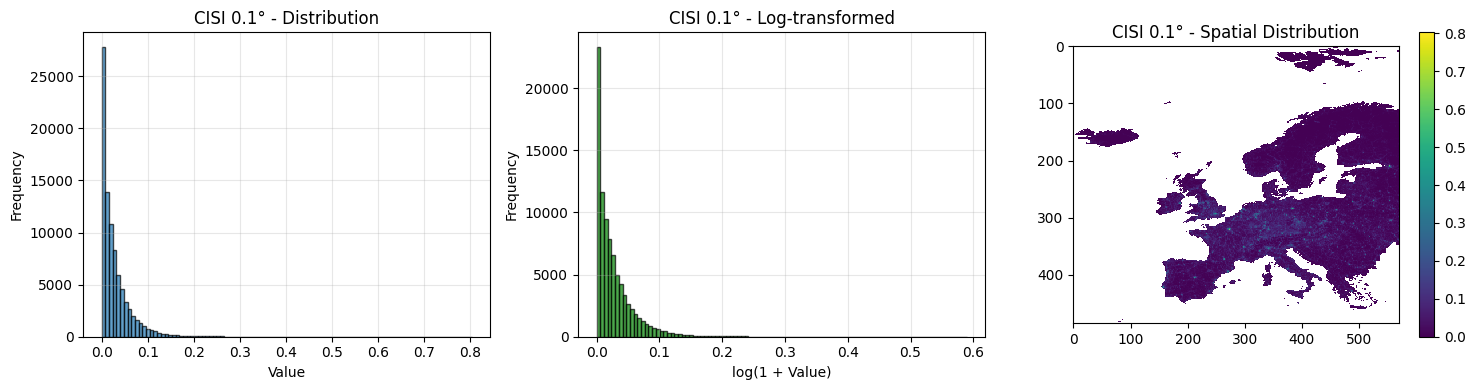

In [5]:
print("\n" + "#" * 70)
print("### 0.1 DEGREE RESOLUTION FILES ###")
print("#" * 70 + "\n")

# Update these paths to your actual 0.1 degree files
gdp_01_path = r'READY_data\inputs\2019_gdp_aligned_010.tif'
pop_01_path = r'READY_data\inputs\2020_pop_aligned_010.tif'
lc_01_path = r'READY_data\landuse_onehot\clipped_history_2020_onehot.tif'  # Adjust if different
cisi_01_path = r'READY_data\labels\2024_CISI_010deg.tif'  # Adjust if different

# GDP 0.1 degree
gdp_01 = inspect_raster(gdp_01_path, 'GDP 0.1°')

# Population 0.1 degree
pop_01 = inspect_raster(pop_01_path, 'Population 0.1°')

# Land Cover 0.1 degree (just first channel)
with rasterio.open(lc_01_path) as src:
    lc_01_first = src.read(1).astype(np.float32)
    print("=" * 60)
    print(f"INSPECTING: Land Cover 0.1° (Channel 1 of {src.count})")
    print("=" * 60)
    print(f"Total channels: {src.count}")
    print(f"Shape per channel: {lc_01_first.shape}")
    print(f"Valid values in Channel 1: {(lc_01_first >= 0).sum():,}")
    print("\n")

# CISI 0.1 degree
cisi_01 = inspect_raster(cisi_01_path, 'CISI 0.1°')

# Check overlap for 0.1 degree

### 0.1 DEGREE - DATA OVERLAP ANALYSIS ###

Total pixels: 276,450

Valid pixels per dataset:
  GDP:  276,450 (100.00%)
  Pop:  276,450 (100.00%)
  CISI: 87,346 (31.60%)

✅ Pixels valid in ALL datasets: 87,346 (31.60%)


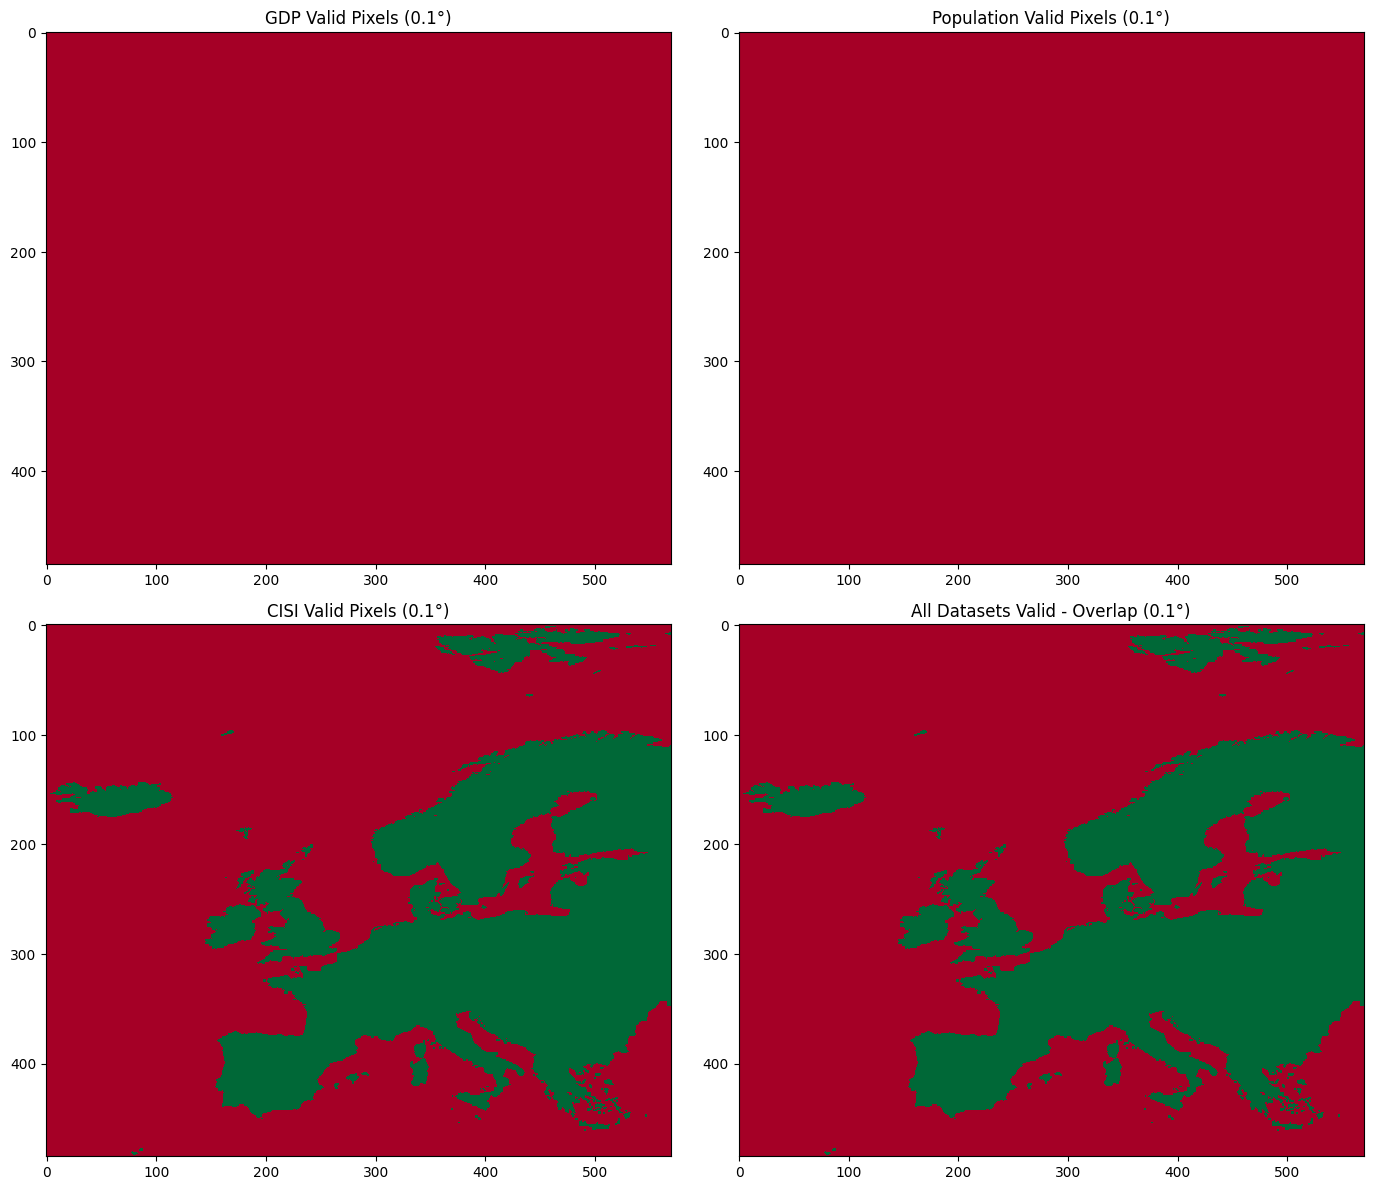

In [6]:
print("=" * 70)
print("### 0.1 DEGREE - DATA OVERLAP ANALYSIS ###")
print("=" * 70)

# Create masks
gdp_valid_01 = ~np.isnan(gdp_01)
pop_valid_01 = ~np.isnan(pop_01)
cisi_valid_01 = ~np.isnan(cisi_01)

total_pixels_01 = gdp_01.size

print(f"\nTotal pixels: {total_pixels_01:,}")
print(f"\nValid pixels per dataset:")
print(f"  GDP:  {gdp_valid_01.sum():,} ({gdp_valid_01.sum()/total_pixels_01*100:.2f}%)")
print(f"  Pop:  {pop_valid_01.sum():,} ({pop_valid_01.sum()/total_pixels_01*100:.2f}%)")
print(f"  CISI: {cisi_valid_01.sum():,} ({cisi_valid_01.sum()/total_pixels_01*100:.2f}%)")

# Overlap
all_valid_01 = gdp_valid_01 & pop_valid_01 & cisi_valid_01
print(f"\n✅ Pixels valid in ALL datasets: {all_valid_01.sum():,} ({all_valid_01.sum()/total_pixels_01*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(gdp_valid_01, cmap='RdYlGn', interpolation='nearest')
axes[0, 0].set_title('GDP Valid Pixels (0.1°)')

axes[0, 1].imshow(pop_valid_01, cmap='RdYlGn', interpolation='nearest')
axes[0, 1].set_title('Population Valid Pixels (0.1°)')

axes[1, 0].imshow(cisi_valid_01, cmap='RdYlGn', interpolation='nearest')
axes[1, 0].set_title('CISI Valid Pixels (0.1°)')

axes[1, 1].imshow(all_valid_01, cmap='RdYlGn', interpolation='nearest')
axes[1, 1].set_title('All Datasets Valid - Overlap (0.1°)')

plt.tight_layout()
plt.show()

print("\n")

# SUMMARY

In [7]:
print("\n" + "=" * 70)
print("### SUMMARY COMPARISON ###")
print("=" * 70)

print("\n0.25 DEGREE:")
print(f"  Total pixels: {total_pixels_025:,}")
print(f"  Usable pixels (all valid): {all_valid_025.sum():,} ({all_valid_025.sum()/total_pixels_025*100:.2f}%)")

print("\n0.1 DEGREE:")
print(f"  Total pixels: {total_pixels_01:,}")
print(f"  Usable pixels (all valid): {all_valid_01.sum():,} ({all_valid_01.sum()/total_pixels_01*100:.2f}%)")

print("\n" + "=" * 70)


### SUMMARY COMPARISON ###

0.25 DEGREE:
  Total pixels: 44,232
  Usable pixels (all valid): 14,922 (33.74%)

0.1 DEGREE:
  Total pixels: 276,450
  Usable pixels (all valid): 87,346 (31.60%)



# Cleaning pop and GDP

In [8]:
def clean_and_normalize_raster(input_path, output_path):
    """
    Clean extreme values and normalize a raster file.
    Handles improperly flagged nodata values.
    """
    with rasterio.open(input_path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata_metadata = src.nodata
    
    print(f"Processing: {os.path.basename(input_path)}")
    print(f"  Original shape: {data.shape}")
    
    # Step 1: Handle metadata nodata
    if nodata_metadata is not None:
        print(f"  Metadata nodata: {nodata_metadata}")
        data[data == nodata_metadata] = np.nan
    
    # Step 2: Handle common nodata values that might not be in metadata
    # This is the KEY fix for -3.4e38 issue
    nodata_flags = [
        -3.4028235e+38,  # Float32 min
        -3.402823e+38,   # Slight variation
        -9999,
        -32768,
    ]
    
    for flag in nodata_flags:
        mask = np.isclose(data, flag, rtol=1e-5)
        if mask.sum() > 0:
            print(f"  Found {mask.sum():,} pixels with value ≈ {flag:.2e} (treating as nodata)")
            data[mask] = np.nan
    
    # Step 3: Remove any remaining extreme negatives
    extreme_mask = data < -1e10
    if extreme_mask.sum() > 0:
        print(f"  Found {extreme_mask.sum():,} extreme negative values (< -1e10), setting to NaN")
        data[extreme_mask] = np.nan
    
    # Step 4: Remove infinities
    inf_mask = np.isinf(data)
    if inf_mask.sum() > 0:
        print(f"  Found {inf_mask.sum():,} infinite values, setting to NaN")
        data[inf_mask] = np.nan
    
    # Step 5: Get valid data
    valid_mask = ~np.isnan(data)
    
    if valid_mask.sum() == 0:
        print("  ⚠️ WARNING: No valid data after cleaning!")
        return
    
    data_valid = data[valid_mask]
    print(f"  Valid pixels after cleaning: {valid_mask.sum():,} ({valid_mask.sum()/data.size*100:.2f}%)")
    print(f"  Cleaned data range: [{data_valid.min():.2f}, {data_valid.max():.2f}]")
    
    # Step 6: Log transform (helps with skewed GDP/Pop distributions)
    # Only for non-negative data
    if data_valid.min() < 0:
        print(f"  ⚠️ Warning: Found negative values after cleaning. Using absolute value.")
        data_valid = np.abs(data_valid)
    
    data_valid_log = np.log1p(data_valid)
    
    # Step 7: Standardize (mean=0, std=1)
    mean_val = data_valid_log.mean()
    std_val = data_valid_log.std()
    
    data_normalized = np.full_like(data, np.nan)
    
    # Apply log + standardization to valid pixels
    temp_log = np.log1p(np.abs(data[valid_mask]))
    data_normalized[valid_mask] = (temp_log - mean_val) / (std_val + 1e-8)
    
    print(f"  Normalized - Mean: {np.nanmean(data_normalized):.4f}, Std: {np.nanstd(data_normalized):.4f}")
    print(f"  Normalized range: [{np.nanmin(data_normalized):.4f}, {np.nanmax(data_normalized):.4f}]")
    
    # Step 8: Save
    profile.update(dtype=rasterio.float32, nodata=np.nan)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(data_normalized, 1)
    
    print(f"  ✅ Saved to: {output_path}\n")

# 0.25 degree files

In [9]:
output_dir = r'READY_data\inputs_normalized'

print("=" * 70)
print("PROCESSING 0.25 DEGREE FILES")
print("=" * 70 + "\n")

# GDP 0.25 degree
clean_and_normalize_raster(
    r'READY_data\inputs\2019_gdp_aligned_025.tif',
    os.path.join(output_dir, '2019_gdp_aligned_025_normalized.tif')
)

# Population 0.25 degree
clean_and_normalize_raster(
    r'READY_data\inputs\2020_pop_aligned_025.tif',
    os.path.join(output_dir, '2020_pop_aligned_025_normalized.tif')
)

print("\n✅ 0.25 DEGREE FILES COMPLETE!")

PROCESSING 0.25 DEGREE FILES

Processing: 2019_gdp_aligned_025.tif
  Original shape: (194, 228)
  Found 29,955 pixels with value ≈ -3.40e+38 (treating as nodata)
  Valid pixels after cleaning: 14,277 (32.28%)
  Cleaned data range: [0.00, 85.08]
  Normalized - Mean: -0.0000, Std: 1.0000
  Normalized range: [-1.0483, 4.1557]
  ✅ Saved to: READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif

Processing: 2020_pop_aligned_025.tif
  Original shape: (194, 228)
  Found 26,272 pixels with value ≈ -3.40e+38 (treating as nodata)
  Valid pixels after cleaning: 17,960 (40.60%)
  Cleaned data range: [0.00, 7465659.50]
  Normalized - Mean: -0.0000, Std: 1.0000
  Normalized range: [-2.2972, 2.2874]
  ✅ Saved to: READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif


✅ 0.25 DEGREE FILES COMPLETE!


In [10]:
print("\n" + "=" * 70)
print("PROCESSING 0.1 DEGREE FILES")
print("=" * 70 + "\n")

# GDP 0.1 degree
clean_and_normalize_raster(
    r'READY_data\inputs\2019_gdp_aligned_010.tif',
    os.path.join(output_dir, '2019_gdp_aligned_010_normalized.tif')
)

# Population 0.1 degree
clean_and_normalize_raster(
    r'READY_data\inputs\2020_pop_aligned_010.tif',
    os.path.join(output_dir, '2020_pop_aligned_010_normalized.tif')
)

print("\n✅ 0.1 DEGREE FILES COMPLETE!")


PROCESSING 0.1 DEGREE FILES

Processing: 2019_gdp_aligned_010.tif
  Original shape: (485, 570)
  Found 187,053 pixels with value ≈ -3.40e+38 (treating as nodata)
  Valid pixels after cleaning: 89,397 (32.34%)
  Cleaned data range: [0.00, 101.49]
  Normalized - Mean: -0.0000, Std: 1.0000
  Normalized range: [-0.8871, 4.2553]
  ✅ Saved to: READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif

Processing: 2020_pop_aligned_010.tif
  Original shape: (485, 570)
  Found 171,511 pixels with value ≈ -3.40e+38 (treating as nodata)
  Valid pixels after cleaning: 104,939 (37.96%)
  Cleaned data range: [0.00, 3436316.25]
  Normalized - Mean: -0.0000, Std: 1.0000
  Normalized range: [-2.0244, 2.9402]
  ✅ Saved to: READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif


✅ 0.1 DEGREE FILES COMPLETE!


# Verify results in inputs_normalized

In [11]:
print("\n" + "=" * 70)
print("VERIFICATION OF NORMALIZED FILES")
print("=" * 70)

for res in ['025', '010']:
    print(f"\n### {res.replace('0', '0.')}° RESOLUTION ###")
    
    for var, year in [('gdp', '2019'), ('pop', '2020')]:
        file_path = os.path.join(output_dir, f'{year}_{var}_aligned_{res}_normalized.tif')
        
        with rasterio.open(file_path) as src:
            data = src.read(1)
            valid = ~np.isnan(data)
            
            print(f"\n{var.upper()} {res.replace('0', '0.')}°:")
            print(f"  Valid pixels: {valid.sum():,} ({valid.sum()/data.size*100:.2f}%)")
            print(f"  Range: [{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]")
            print(f"  Mean: {np.nanmean(data):.4f}")
            print(f"  Std: {np.nanstd(data):.4f}")
            
            # Check for remaining extreme values
            if valid.sum() > 0:
                extreme_count = ((data < -10) | (data > 10)).sum()
                print(f"  Extreme values (|x| > 10): {extreme_count}")

print("\n" + "=" * 70)
print("✅ ALL FILES PROCESSED AND VERIFIED!")
print("=" * 70)



VERIFICATION OF NORMALIZED FILES

### 0.25° RESOLUTION ###

GDP 0.25°:
  Valid pixels: 14,277 (32.28%)
  Range: [-1.0483, 4.1557]
  Mean: -0.0000
  Std: 1.0000
  Extreme values (|x| > 10): 0

POP 0.25°:
  Valid pixels: 17,960 (40.60%)
  Range: [-2.2972, 2.2874]
  Mean: -0.0000
  Std: 1.0000
  Extreme values (|x| > 10): 0

### 0.10.° RESOLUTION ###

GDP 0.10.°:
  Valid pixels: 89,397 (32.34%)
  Range: [-0.8871, 4.2553]
  Mean: -0.0000
  Std: 1.0000
  Extreme values (|x| > 10): 0

POP 0.10.°:
  Valid pixels: 104,939 (37.96%)
  Range: [-2.0244, 2.9402]
  Mean: -0.0000
  Std: 1.0000
  Extreme values (|x| > 10): 0

✅ ALL FILES PROCESSED AND VERIFIED!
